In [53]:
import asyncio
import json
import time
from urllib.request import urlopen
import hid
import serial
import serial.tools.list_ports
import websockets
import copy
from windfreak import SynthHD
from RsInstrument import RsInstrument, BinFloatFormat
import skrf as rf
import matplotlib.pyplot as plt
import numpy as np
import pyvisa
from datetime import datetime
from pathlib import Path
import os
import sys

states = {
    "short": [0, 0, 0x00, 0x08, 0x00, 0x00, 0x08, 0x00],
    "open": [0, 0, 0x00],
    "load": [0, 0, 0x00, 0x00, 0x01, 0x00, 0x00, 0x01],
    "port1": [0, 0, 0x14, 0x20, 0x04, 0x14, 0x20, 0x04],
    "port2": [0, 0, 0x04, 0x10, 0x44, 0x04, 0x10, 0x44],
    "port3": [0, 0, 0x01, 0x01, 0x82, 0x01, 0x01, 0x82],
    "port4": [0, 0, 0x00, 0x82, 0x82, 0x00, 0x82, 0x82],
    "port5": [0, 0, 0x02, 0x04, 0x82, 0x02, 0x04, 0x82],
    "port6": [0, 0, 0x0C, 0x40, 0x04, 0x0C, 0x40, 0x04],
}

commands = {
    "short": b"s",
    "open": b"o",
    "load": b"l",
    "port1": b"1",
    "port2": b"2",
    "port3": b"3",
    "port4": b"4",
    "port5": b"5",
    "port6": b"6",
}

WARM_SWITCHES_1_IP_ADDRESS = '169.254.10.10'
WARM_SWITCHES_2_IP_ADDRESS = '169.254.12.12'
PROGRAMMABLE_ATTENUATOR_IP_ADDRESS = '169.254.11.11'

def send_url_command(ip_address, cmd_to_send):
    url = f"http://{ip_address}/:{cmd_to_send}"
    for attempt in range(3):
        try:
            with urlopen(url, timeout=3) as response:
                pte_return = response.read()
            if len(pte_return) > 100:
                print(f"Error, command not found: {url}")
                return "Invalid Command!"
            return pte_return.decode('utf-8').strip()
        except Exception as network_err:
            if attempt == 2:
                print(f"Hardware Network Warning: No response from {ip_address}. Error: {network_err}")
                return "No Response!"
            time.sleep(0.05)
            
def set_warm_switches_by_ip(ip_address, A, B, C, D):
    state_byte = 128 + int(A) + (2 * int(B)) + (4 * int(C)) + (8 * int(D))
    return send_url_command(ip_address, f"SETP={state_byte}")
    
def set_warm_switches(A1, B1, C1, D1, A2, B2, C2, D2):
    response_1 = set_warm_switches_by_ip(WARM_SWITCHES_1_IP_ADDRESS, A1, B1, C1, D1)
    response_2 = set_warm_switches_by_ip(WARM_SWITCHES_2_IP_ADDRESS, A2, B2, C2, D2)
    return response_1, response_2

def configure_warm_switches():
    measurement_type = state["measurement_select"]
    scattering_parameter = state["s_parameter_select"]
    twpa_pump = state["twpa_pump_select"]
    jpa_pump = state["jpa_pump_select"]

    warm_switch_1_A = 0
    warm_switch_1_B = 0
    warm_switch_1_C = 0
    warm_switch_1_D = 0
    warm_switch_2_A = 0
    warm_switch_2_B = 0
    warm_switch_2_C = 0
    warm_switch_2_D = 0

    if measurement_type == "vna":
        warm_switch_2_B = 0
        warm_switch_2_C = 0
    elif measurement_type == "spectrum_analyzer_fridge":
        warm_switch_2_B = 0
        warm_switch_2_C = 1
    elif measurement_type == "spectrum_analyzer_diode":
        warm_switch_2_B = 1
        warm_switch_2_C = 1

    if scattering_parameter in ["s11", "s12", "s13", "s14"]:
        warm_switch_2_A = 0
    elif scattering_parameter in ["s21", "s22", "s23", "s24"]:
        warm_switch_2_A = 1

    if scattering_parameter in ["s11", "s21"]:
        warm_switch_1_A = 0
        warm_switch_1_B = 0
    elif scattering_parameter in ["s12", "s22"]:
        warm_switch_1_A = 0
        warm_switch_1_B = 1
        warm_switch_1_C = 0
    elif scattering_parameter in ["s13", "s23"]:
        warm_switch_1_A = 1
        warm_switch_1_B = 0
        warm_switch_1_C = 0
    elif scattering_parameter in ["s14", "s24"]:
        warm_switch_1_A = 1
        warm_switch_1_B = 0
        warm_switch_1_C = 1

    if twpa_pump == "twpa_pump_1":
        warm_switch_1_D = 0
    elif twpa_pump == "twpa_pump_2":
        warm_switch_1_D = 1

    if jpa_pump == "jpa_pump_1":
        warm_switch_2_D = 0
    elif jpa_pump == "jpa_pump_2":
        warm_switch_2_D = 1

    set_warm_switches(
        warm_switch_1_A,
        warm_switch_1_B,
        warm_switch_1_C,
        warm_switch_1_D,
        warm_switch_2_A,
        warm_switch_2_B,
        warm_switch_2_C,
        warm_switch_2_D,
    )
    
def set_programmable_attenuator(attenuation):
    send_url_command(PROGRAMMABLE_ATTENUATOR_IP_ADDRESS, f"SETATT={attenuation}")

def get_port_by_serial(serial_num):
    for p in serial.tools.list_ports.comports():
        if p.serial_number == serial_num:
            return p.device
    raise RuntimeError(f"Switch with serial {serial_num} not found!")

def set_cold_thru_switch_pair(state_string):
    if state_string in states:
        data = states[state_string]
        cold_thru_switch_pair.write(data)
        cold_thru_switch_pair.write([0, 2])
        print(state_string)

def set_cold_output_switch(switch_device, state_string):
    if state_string in commands:
        switch_device.write(commands[state_string])
        print(f"{state_string}")

switch_1_serial = "342393133353518022E0"
switch_2_serial = "3423232363135150A1D2"

cold_output_switch_1 = serial.Serial(
    get_port_by_serial(switch_1_serial), 9600, write_timeout=0
)
cold_output_switch_2 = serial.Serial(
    get_port_by_serial(switch_2_serial), 9600, write_timeout=0
)

VID = 0x04D8
PID = 0xEDFB

cold_thru_switch_pair = hid.device()
cold_thru_switch_pair.open(VID, PID)

with open("state.json", "r") as f:
    state = json.load(f)
previous_state = copy.deepcopy(state)

time.sleep(1)
set_cold_output_switch(cold_output_switch_1,state["cold_output_switch_1"])
set_cold_output_switch(cold_output_switch_2,state["cold_output_switch_2"])
set_cold_thru_switch_pair(state['cold_thru_switch_pair'])
configure_warm_switches()
set_programmable_attenuator(state['programmable_attenuator'])

cold_output_switch_1.close()
cold_output_switch_2.close()
cold_thru_switch_pair.close()

port1
port1
port1


port1
port1
short


'port1'

In [54]:
cold_output_switch_1.close()
cold_output_switch_2.close()
cold_thru_switch_pair.close()

In [56]:
state

{'vna_idn': 'Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30',
 'vna_source_power': -29,
 'vna_if_bandwidth': 10000,
 'vna_start_frequency': 4000000000,
 'vna_stop_frequency': 8000000000,
 'vna_number_of_points': 1001,
 'spa_resolution_bandwidth': 1000000,
 'spa_video_bandwidth': 10000,
 'spa_units': 'W',
 'spa_idn': 'Hewlett-Packard, E7405A, SG45102671, A.14.04',
 'spa_start_frequency': 4000000000,
 'spa_stop_frequency': 8000000000,
 'spa_number_of_points': 1001,
 'cold_output_switch_1': 'port1',
 'cold_output_switch_2': 'port1',
 'cold_thru_switch_pair': 'port1',
 's_parameter_select': 's21',
 'measurement_select': 'vna',
 'twpa_pump_select': 'twpa_pump_1',
 'jpa_pump_select': 'jpa_pump_1',
 'programmable_attenuator': 0,
 'temperature': 0.02,
 'date': '04-08-26',
 'time': '00:06:49',
 'timestamp': 1785860990,
 'data_repository': 'https://github.com/lafefspietz/qna-data-summer-2026/',
 'jpa1': {'pump_power': -30,
  'pump_frequency': 13000000000,
  'flux_bias': 0.75,
  'volts_per_phi0'

In [58]:
rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break

In [59]:
vna.go_to_local()

In [60]:
spa = None
for instrument in instruments:
    if '7405' in instrument:
        spa = rm.open_resource(instrument) 
        break

In [63]:
with open("state.json", "r") as f:
    state = json.load(f)
spa.write(f":SENS1:FREQ:START {state['spa_start_frequency']}")
spa.write(f":SENS1:FREQ:STOP {state['spa_stop_frequency']}")
spa.write(f":SENS1:SWEep:POINts {state['spa_number_of_points']}")
spa.write(f":SENS:BAND {state['spa_resolution_bandwidth']}")
spa.write(f":SENS:BAND:VID {state['spa_video_bandwidth']}")



15

In [65]:
print(vna.query('*IDN?').strip())
vna.go_to_local()

Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30


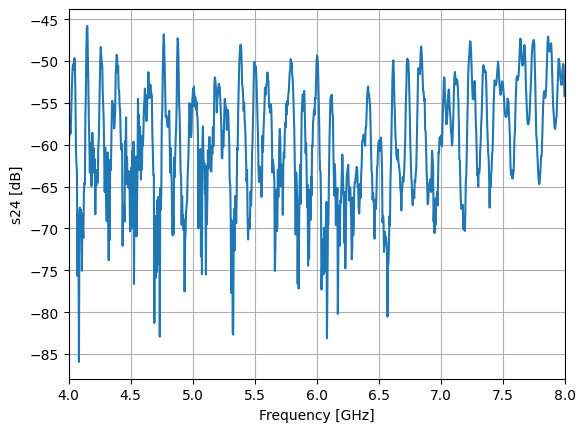

In [67]:
vna.visa_timeout = 60000 

frequencies = np.linspace(state['vna_start_frequency'],state['vna_stop_frequency'],state['vna_number_of_points'])
fghz = frequencies/1e9

vna.bin_float_numbers_format = BinFloatFormat.Single_4bytes
vna.write("FORM REAL,32") 
vna.write_str(":CALC1:PAR:SEL 'Trc1'") 
vna.write("INITiate:CONTinuous OFF")
vna.write("INITiate:IMMediate")  
opc_done = vna.query("*OPC?").strip()

if opc_done != "1":
    print(f"Error: OPC returned unexpected value '{opc_done}'; ending execution.")
    exit()

raw_floats = vna.query_bin_or_ascii_float_list(":CALC1:DATA? SDAT")

vna.write("INITiate:CONTinuous ON")
vna.go_to_local()

real_parts = np.array(raw_floats[0::2])
imag_parts = np.array(raw_floats[1::2])
complex_trace = real_parts + 1j * imag_parts

s_matrix = np.zeros((len(frequencies), 1, 1), dtype=complex)
s_matrix[:, 0, 0] = complex_trace
trace_network = rf.Network(frequency=frequencies, s=s_matrix, name='data trace')
trace = trace_network.s_db[:,0,0]

plt.plot(fghz, trace)
plt.xlim(fghz[0], fghz[-1])
#plt.ylim(-80, 10)
plt.grid()
plt.xlabel('Frequency [GHz]')
plt.ylabel('s24 [dB]')
#plt.title('direct path')
#plt.savefig('vna-trace.png', dpi=300, bbox_inches='tight')
plt.show()

#trace_network.write('vna-trace.s1p')
#with open('vna-settings.json', 'w') as json_file:
#    json.dump(vna_json, json_file, indent=4)

In [68]:
print(spa.query('*IDN?'))

Hewlett-Packard, E7405A, SG45102671, A.14.04



241511.3472489
241511.3495294
241511.4656109
241511.7509342


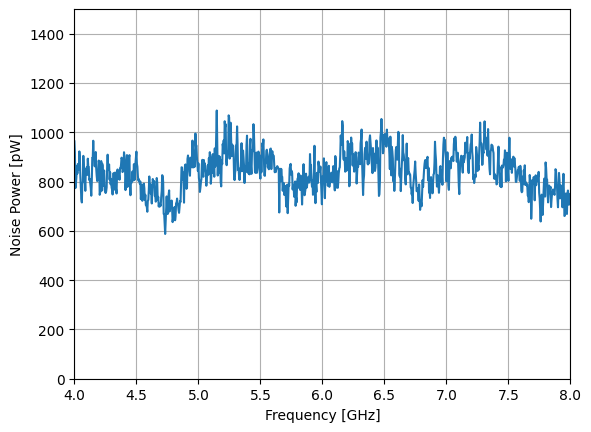

241511.9660662


In [92]:
frequencies = np.linspace(state['spa_start_frequency'],state['spa_stop_frequency'],state['spa_number_of_points'])
fghz = frequencies/1e9

spa.write(":UNIT:POW W")
spa.write("FORM REAL,32")
spa.write("INIT:CONT OFF")
spa.timeout = 30000

spa.write("INIT:IMM")
spa.query("*OPC?")

spa.timeout = 5000
spa_trace = np.array(spa.query_binary_values("TRAC? TRACE1", datatype="f", is_big_endian=True))
spa.write("INIT:CONT ON")

plt.plot(fghz, spa_trace/1e-12)
plt.xlim(fghz[0], fghz[-1])
plt.ylim(0, 1500)
plt.grid()
plt.xlabel('Frequency [GHz]')
plt.ylabel('Noise Power [pW]')
#plt.title('direct path')
#plt.savefig('vna-trace.png', dpi=300, bbox_inches='tight')
plt.show()



In [75]:
plt.plot()

numpy.ndarray

In [90]:
print(time.perf_counter())


237629.8796494


In [137]:
with open("state.json", "r") as f:
    state = json.load(f)


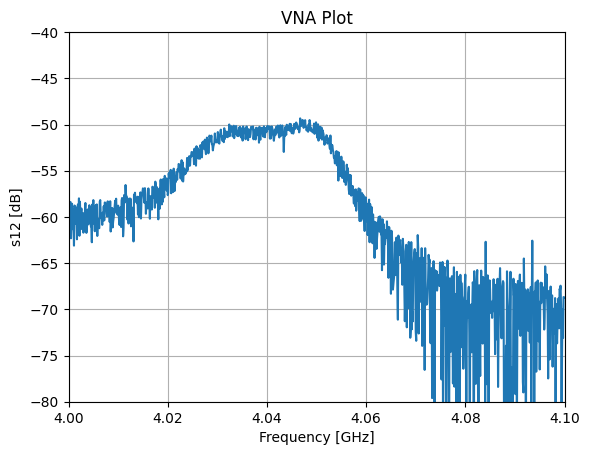

In [160]:
with open("state.json", "r") as f:
    state = json.load(f)
    
now = datetime.now().astimezone()
state['timestamp'] = int(now.timestamp())
state['date'] = now.strftime("%d-%m-%Y")
state['time'] = now.strftime("%H:%M:%S")
state['timezone'] = now.tzname()
try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()
folder_name = datetime.now().strftime("%d-%m-%Y")
target_dir = script_dir / folder_name
target_dir.mkdir(parents=True, exist_ok=True)

readme_path = target_dir / 'README.md'
if not readme_path.exists():
    readme_path.write_text("#  " + state['date'] + " Plots\n\n")

if 'vna' in state['measurement_select']:
    frequencies = np.linspace(state['vna_start_frequency'],state['vna_stop_frequency'],state['vna_number_of_points'])
    fghz = frequencies/1e9
    vna.bin_float_numbers_format = BinFloatFormat.Single_4bytes
    vna.write("FORM REAL,32") 
    vna.write_str(":CALC1:PAR:SEL 'Trc1'") 
    vna.write("INITiate:CONTinuous OFF")
    vna.write("INITiate:IMMediate")  
    opc_done = vna.query("*OPC?").strip()    
    if opc_done != "1":
        print(f"Error: OPC returned unexpected value '{opc_done}'; ending execution.")
        exit()
    raw_floats = vna.query_bin_or_ascii_float_list(":CALC1:DATA? SDAT")
    vna.write("INITiate:CONTinuous ON")
    vna.go_to_local()
    real_parts = np.array(raw_floats[0::2])
    imag_parts = np.array(raw_floats[1::2])
    complex_trace = real_parts + 1j * imag_parts
    s_matrix = np.zeros((len(frequencies), 1, 1), dtype=complex)
    s_matrix[:, 0, 0] = complex_trace
    trace_network = rf.Network(frequency=frequencies, s=s_matrix, name='data trace')
    trace = trace_network.s_db[:,0,0]
    plt.plot(fghz, trace)
    plt.xlim(fghz[0], fghz[-1])
    plt.ylim(state['vna_plot_scale_minimum'],state['vna_plot_scale_maximum'])
    plt.title(state['vna_plot_title'])
    plt.grid()
    plt.xlabel('Frequency [GHz]')
    plt.ylabel(state['s_parameter_select'] + ' [dB]')
    plot_file_name = f"{state['timestamp']}-vna-plot.png"
    plot_file_path = target_dir / plot_file_name
    plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
    touchstone_file_name = f"{state['timestamp']}-vna-trace.s1p"
    touchstone_file_path = target_dir / touchstone_file_name
    trace_network.write_touchstone(str(touchstone_file_path))
    with open(readme_path, "a") as file:
        file.write("![]("+ plot_file_name + ")")

    
if 'spectrum_analyzer' in state['measurement_select']:
    frequencies = np.linspace(state['spa_start_frequency'],state['spa_stop_frequency'],state['spa_number_of_points'])
    fghz = frequencies/1e9
    spa.write(":UNIT:POW W")
    spa.write("FORM REAL,32")
    spa.write("INIT:CONT OFF")
    spa.timeout = 30000    
    spa.write("INIT:IMM")
    spa.query("*OPC?")
    spa.timeout = 5000
    spa_trace = np.array(spa.query_binary_values("TRAC? TRACE1", datatype="f", is_big_endian=True))
    spa.write("INIT:CONT ON")
    plt.plot(fghz, spa_trace/1e-12)
    plt.xlim(fghz[0], fghz[-1])
    plt.ylim(state['spa_plot_minimum'], state['spa_plot_maximum'])
    plt.grid()
    plt.xlabel('Frequency [GHz]')
    plt.title(state['spa_plot_title'])
    plt.ylabel(state['spa_ylabel'])
    
    plot_file_name = f"{state['timestamp']}-spa-plot.png"
    plot_file_path = target_dir / plot_file_name
    plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
    trace_file_name = f"{state['timestamp']}-spa-trace.json"
    file_path = target_dir / trace_file_name
    spa_trace_data  = {}
    spa_trace_data['fghz']  = fghz.tolist()
    spa_trace_data['trace'] = (spa_trace/1e-12).tolist()
    spa_trace_data['unit'] = "pW"
    spa_trace_data['vbw'] = state['spa_video_bandwidth']
    spa_trace_data['rbw'] = state['spa_resolution_bandwidth']
    with open(readme_path, "a") as file:
        file.write("![]("+ plot_file_name + ")")
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(spa_trace_data, f, indent=4)
    
state_file_name = f"{state['timestamp']}-state.json"
state['file_name'] = state_file_name
state['state_file_url'] = state['data_url_base'] + folder_name + "/" +  state['file_name']
file_path = target_dir / state_file_name
with open(file_path, "w", encoding="utf-8") as f:
    json.dump(state, f, indent=4)

main_state_file_name = "state.json"
file_path = script_dir / main_state_file_name
with open(file_path, "w", encoding="utf-8") as f:
    json.dump(state, f, indent=4)

In [117]:
str(state['timestamp']) + '-state.json'

'1786121922-state.json'

In [119]:
file_name = f"{state['timestamp']}-state.json"
file_path = target_dir / file_name

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(state, f, indent=4)


In [128]:
1.2*max(spa_trace)

np.float64(1.3061144166215398e-09)

In [152]:
readme_path = target_dir / 'README.md'
if not readme_path.exists():
    readme_path.write_text("#  " + state['date'] + " Plots\n\n")

In [134]:
file_name = f"{state['timestamp']}-state.json"
state['file_name'] = file_name

In [138]:
state

{'vna_idn': 'Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30',
 'vna_source_power': 0,
 'vna_if_bandwidth': 10000,
 'vna_start_frequency': 4000000000,
 'vna_stop_frequency': 4100000000,
 'vna_number_of_points': 1001,
 'vna_plot_scale_minimum': -80,
 'vna_plot_scale_maximum': -40,
 'vna_plot_title': 'VNA Plot',
 'spa_resolution_bandwidth': 5000000,
 'spa_video_bandwidth': 10000,
 'spa_units': 'W',
 'spa_idn': 'Hewlett-Packard, E7405A, SG45102671, A.14.04',
 'spa_start_frequency': 6000000000,
 'spa_stop_frequency': 6500000000,
 'spa_number_of_points': 1001,
 'spa_plot_title': 'Spectrum Analyzer Trace',
 'spa_plot_minimum': 0,
 'spa_plot_maximum': 1.5e-09,
 'spa_ylabel': 'Noise Power [pW]',
 'cold_output_switch_1': 'port1',
 'cold_output_switch_2': 'port1',
 'cold_thru_switch_pair': 'port1',
 's_parameter_select': 's12',
 'measurement_select': 'spectrum_analyzer_fridge',
 'twpa_pump_select': 'twpa_pump_1',
 'jpa_pump_select': 'jpa_pump_1',
 'programmable_attenuator': 0,
 'temperature': 0.

In [158]:
str(touchstone_file_path)


'C:\\local-web-server\\Apache\\htdocs\\qna-data-summer-2026\\07-08-2026\\1786136953-vna-trace.s1p'